# MURA DINOv2 Attention-MIL + MLflow

Self-contained Colab notebook: it mounts Google Drive, extracts MURA, freezes DINOv2, precomputes one embedding tensor per study, trains a gated Attention-MIL head with `batch_size=1` and gradient accumulation, logs the experiment to MLflow on the VPS, and registers the final MIL head model.

Recommended workflow: set `VPS_HOST`, run the notebook once to generate persistent embeddings in Drive, then train from the local `/content` embedding cache for fast MIL experiments.


In [8]:
# Install MLflow dependencies if the runtime does not have them yet.
import importlib.util
import subprocess
import sys

missing = [pkg for pkg in ["mlflow", "boto3", "psycopg2"] if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "mlflow>=2.15.1,<3",
        "boto3",
        "psycopg2-binary",
    ])
else:
    print("MLflow dependencies are already installed")


MLflow dependencies are already installed


In [9]:
import json
import os
import random
import sys
import time
import zipfile
from pathlib import Path

import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from mlflow.tracking import MlflowClient
from tqdm.auto import tqdm

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
NVIDIA A100-SXM4-80GB


## Config

The notebook is self-contained. It mounts Drive, extracts the MURA archive if needed, writes DINOv2 embeddings to Drive for persistence, mirrors them into `/content`, and then trains Attention-MIL from the local cache.


In [10]:
# Colab/runtime constants. Change VPS_HOST before running with MLflow logging.
VPS_HOST = ""  # example: "203.0.113.10"
MLFLOW_TRACKING_URI = f"http://{VPS_HOST}:8094"
EXPERIMENT_NAME = "project2025-mura-dinov2-attention-mil"
REGISTERED_MODEL_NAME = "mura_dinov2_attention_mil"
RUN_NAME = "dinov2_attention_mil_frozen_embeddings"
MODEL_VERSION_ALIAS = "prd"
MLFLOW_ENABLED = True

SEED = 42
BACKBONE_NAME = "dinov2_vitl14"
IMAGE_SIZE = 448
EMBED_BATCH_SIZE = 768
NUM_WORKERS = 2

EPOCHS = 30
ACCUMULATION_STEPS = 16
LR = 1e-3
WEIGHT_DECAY = 1e-2
ATTENTION_DIM = 256
DROPOUT = 0.1
MAX_GRAD_NORM = 1.0
THRESHOLD = 0.5
INTERNAL_VAL_SIZE = 0.10

ONLY_ANATOMY = None  # Example: "XR_WRIST" for a quick single-anatomy experiment.
LIMIT_STUDIES = None  # Example: 100 for a smoke test.
OVERWRITE_EMBEDDINGS = False
COPY_ZIP_TO_LOCAL_DISK = True
USE_LOCAL_EMBEDDINGS_FOR_TRAINING = True

if IN_COLAB:
    DRIVE_ROOT = Path("/content/drive/MyDrive/Project2025/attention_mil_dinov2-mil")
    MURA_ZIP_PATH = Path("/content/drive/MyDrive/Project2025/MURA-v1.1-resized-448x448.zip")
    LOCAL_ZIP_PATH = Path("/content/MURA-v1.1-resized-448x448.zip")
    DATA_EXTRACT_DIR = Path("/content/mura_attention_mil_data")
else:
    DRIVE_ROOT = Path("../data/mura_attention_mil")
    MURA_ZIP_PATH = Path("../MURA-v1.1-resized-448x448.zip")
    LOCAL_ZIP_PATH = MURA_ZIP_PATH
    DATA_EXTRACT_DIR = Path("../")

DATA_ROOT = DATA_EXTRACT_DIR / "MURA-v1.1-resized-448x448"
EMBEDDINGS_DIR = DRIVE_ROOT / "embeddings" / f"{BACKBONE_NAME}_{IMAGE_SIZE}"
LOCAL_EMBEDDINGS_DIR = Path("/content/mura_attention_mil_embeddings") / f"{BACKBONE_NAME}_{IMAGE_SIZE}" if IN_COLAB else EMBEDDINGS_DIR
TRAIN_EMBEDDINGS_DIR = LOCAL_EMBEDDINGS_DIR if IN_COLAB and USE_LOCAL_EMBEDDINGS_FOR_TRAINING else EMBEDDINGS_DIR
CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints"
RESULTS_DIR = DRIVE_ROOT / "results"
ARTIFACT_DIR = DRIVE_ROOT / "artifacts"

paths_to_create = [DRIVE_ROOT, EMBEDDINGS_DIR, CHECKPOINT_DIR, RESULTS_DIR, ARTIFACT_DIR, DATA_EXTRACT_DIR]
if TRAIN_EMBEDDINGS_DIR != EMBEDDINGS_DIR:
    paths_to_create.append(TRAIN_EMBEDDINGS_DIR)

for path in paths_to_create:
    path.mkdir(parents=True, exist_ok=True)

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("drive root:", DRIVE_ROOT)
print("data root:", DATA_ROOT)
print("persistent embeddings dir:", EMBEDDINGS_DIR)
print("training embeddings dir:", TRAIN_EMBEDDINGS_DIR)

if MLFLOW_ENABLED:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print("MLflow tracking URI:", mlflow.get_tracking_uri())


drive root: /content/drive/MyDrive/Project2025/attention_mil_dinov2-mil
data root: /content/mura_attention_mil_data/MURA-v1.1-resized-448x448
persistent embeddings dir: /content/drive/MyDrive/Project2025/attention_mil_dinov2-mil/embeddings/dinov2_vitl14_448
training embeddings dir: /content/mura_attention_mil_embeddings/dinov2_vitl14_448
MLflow tracking URI: http://:8094


In [11]:
def resolve_zip_path() -> Path:
    candidates = [MURA_ZIP_PATH, LOCAL_ZIP_PATH, Path("/content/MURA-v1.1-resized-448x448.zip")]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"MURA zip not found. Expected: {MURA_ZIP_PATH}")


def prepare_zip_for_extraction(zip_path: Path) -> Path:
    if not IN_COLAB or not COPY_ZIP_TO_LOCAL_DISK:
        return zip_path
    if zip_path.resolve() == LOCAL_ZIP_PATH.resolve():
        return LOCAL_ZIP_PATH
    if LOCAL_ZIP_PATH.exists() and LOCAL_ZIP_PATH.stat().st_size == zip_path.stat().st_size:
        print("using existing local zip:", LOCAL_ZIP_PATH)
        return LOCAL_ZIP_PATH
    print(f"copying zip to local disk: {zip_path} -> {LOCAL_ZIP_PATH}")
    start = time.time()
    LOCAL_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    import shutil
    shutil.copy2(zip_path, LOCAL_ZIP_PATH)
    print(f"copied in {time.time() - start:.1f}s")
    return LOCAL_ZIP_PATH


def find_mura_root(extract_dir: Path) -> Path:
    candidates = [DATA_ROOT, extract_dir / "MURA-v1.1-resized-448x448", extract_dir / "MURA-v1.1", extract_dir]
    candidates.extend([p for p in extract_dir.rglob("*") if p.is_dir() and p.name.startswith("MURA-v1.1")])
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "valid").is_dir():
            return candidate
    raise FileNotFoundError(f"Could not locate MURA train/valid under {extract_dir}")


if not DATA_ROOT.exists():
    zip_path = prepare_zip_for_extraction(resolve_zip_path())
    print("extracting", zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_EXTRACT_DIR)

DATA_ROOT = find_mura_root(DATA_EXTRACT_DIR)
print("ready:", DATA_ROOT)


ready: /content/mura_attention_mil_data/MURA-v1.1-resized-448x448


## Build study dataframe

In [12]:
def parse_study_path(study_path: Path) -> dict:
    parts = study_path.parts
    split = parts[-4]
    anatomy = parts[-3]
    patient_id = parts[-2]
    study_id = parts[-1]
    label = 1 if "positive" in study_id else 0
    study_key = f"{anatomy}/{patient_id}/{study_id}"
    return {
        "split": split,
        "mil_split": split,
        "anatomy": anatomy,
        "patient_id": patient_id,
        "study_id": study_id,
        "study_key": study_key,
        "label": label,
        "path": str(study_path),
    }


def build_study_dataframe(root_dir: Path) -> pd.DataFrame:
    records = []
    for split in ["train", "valid"]:
        split_dir = root_dir / split
        if not split_dir.exists():
            continue
        for anatomy_dir in sorted(split_dir.iterdir()):
            if not anatomy_dir.is_dir():
                continue
            for patient_dir in sorted(anatomy_dir.iterdir()):
                if not patient_dir.is_dir():
                    continue
                for study_dir in sorted(patient_dir.iterdir()):
                    if study_dir.is_dir():
                        records.append(parse_study_path(study_dir))
    frame = pd.DataFrame(records)
    if ONLY_ANATOMY is not None:
        frame = frame[frame["anatomy"] == ONLY_ANATOMY]
    frame = frame.sort_values(["split", "anatomy", "patient_id", "study_id"]).reset_index(drop=True)
    if LIMIT_STUDIES is not None:
        frame = frame.head(LIMIT_STUDIES)
    return frame


def assign_mil_splits(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["mil_split"] = np.where(frame["split"] == "valid", "test", frame["split"])

    train_source = frame[frame["split"] == "train"].copy()
    train_indices = []
    internal_val_indices = []

    # Split inside anatomy + label buckets to keep the 10% internal val useful for every bone/class.
    for (_, _), part in train_source.groupby(["anatomy", "label"], sort=True):
        if len(part) < 2:
            train_indices.extend(part.index.tolist())
            continue
        splitter = GroupShuffleSplit(n_splits=1, test_size=INTERNAL_VAL_SIZE, random_state=SEED)
        local_train, local_val = next(splitter.split(part, groups=part["study_key"]))
        train_indices.extend(part.iloc[local_train].index.tolist())
        internal_val_indices.extend(part.iloc[local_val].index.tolist())

    frame.loc[train_indices, "mil_split"] = "train"
    frame.loc[internal_val_indices, "mil_split"] = "internal_val"
    return frame.sort_values(["mil_split", "anatomy", "patient_id", "study_id"]).reset_index(drop=True)


studies_df = assign_mil_splits(build_study_dataframe(DATA_ROOT))
print(studies_df.shape)
display(studies_df.groupby(["mil_split", "anatomy", "label"]).size().rename("n").reset_index())
print("original folder split counts:")
display(studies_df.groupby(["split", "mil_split"]).size().rename("n").reset_index())


(14656, 8)


,mil_split,anatomy,label,n
0,internal_val,XR_ELBOW,0,110
1,internal_val,XR_ELBOW,1,66
2,internal_val,XR_FINGER,0,128
3,internal_val,XR_FINGER,1,66
4,internal_val,XR_FOREARM,0,59
5,internal_val,XR_FOREARM,1,29
6,internal_val,XR_HAND,0,150
7,internal_val,XR_HAND,1,53
8,internal_val,XR_HUMERUS,0,33
9,internal_val,XR_HUMERUS,1,28


original folder split counts:


,split,mil_split,n
0,train,internal_val,1352
1,train,train,12105
2,valid,test,1199


## Precompute frozen DINOv2 embeddings

Each study is saved as one `.pt` tensor with shape `[N, 1024]`. Existing files are skipped unless `OVERWRITE_EMBEDDINGS=True`.

In [13]:
class SquarePadResize:
    def __init__(self, size: int, fill: int = 0):
        self.size = size
        self.fill = fill

    def __call__(self, image: Image.Image) -> Image.Image:
        image = image.convert("RGB")
        width, height = image.size
        scale = self.size / max(width, height)
        new_width = max(1, int(round(width * scale)))
        new_height = max(1, int(round(height * scale)))
        image = image.resize((new_width, new_height), Image.BICUBIC)
        canvas = Image.new("RGB", (self.size, self.size), color=(self.fill, self.fill, self.fill))
        canvas.paste(image, ((self.size - new_width) // 2, (self.size - new_height) // 2))
        return canvas


image_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def list_images(study_path: Path) -> list[Path]:
    suffixes = {".png", ".jpg", ".jpeg"}
    return sorted(path for path in study_path.iterdir() if path.suffix.lower() in suffixes)

def embedding_relative_path(row: pd.Series) -> Path:
    return Path(row["split"]) / row["anatomy"] / row["patient_id"] / f"{row['study_id']}.pt"

def load_image_tensor(path: Path) -> torch.Tensor:
    with Image.open(path) as image:
        return image_transform(image)

def batched(items: list[Path], batch_size: int):
    for start in range(0, len(items), batch_size):
        yield items[start:start + batch_size]

def model_features(model: nn.Module, batch: torch.Tensor) -> torch.Tensor:
    output = model(batch)
    if isinstance(output, dict):
        if "x_norm_clstoken" in output:
            output = output["x_norm_clstoken"]
        elif "last_hidden_state" in output:
            output = output["last_hidden_state"][:, 0, :]
        else:
            raise ValueError(f"Cannot infer feature tensor from keys: {list(output)}")
    return output

@torch.inference_mode()
def extract_image_batch_features(model: nn.Module, image_paths: list[Path]) -> torch.Tensor:
    batch = torch.stack([load_image_tensor(path) for path in image_paths]).to(DEVICE, non_blocking=True)
    return model_features(model, batch).detach().cpu().float()


@torch.inference_mode()
def extract_study_features(model: nn.Module, image_paths: list[Path]) -> torch.Tensor:
    chunks = []
    for paths in batched(image_paths, EMBED_BATCH_SIZE):
        chunks.append(extract_image_batch_features(model, paths))
    return torch.cat(chunks, dim=0)


In [14]:
manifest_path = EMBEDDINGS_DIR / "manifest.csv"
local_manifest_path = TRAIN_EMBEDDINGS_DIR / "manifest.csv" if TRAIN_EMBEDDINGS_DIR != EMBEDDINGS_DIR else None

def expected_embed_dim_from_backbone_name(backbone_name: str) -> int:
    known_dims = {
        "dinov2_vits14": 384,
        "dinov2_vitb14": 768,
        "dinov2_vitl14": 1024,
        "dinov2_vitg14": 1536,
    }
    return known_dims.get(backbone_name, 1024)


def build_expected_manifest(frame: pd.DataFrame, embed_dim: int) -> pd.DataFrame:
    rows = []
    for _, row in frame.iterrows():
        study_path = Path(row["path"])
        image_paths = list_images(study_path)
        if not image_paths:
            continue

        manifest_row = row.to_dict()
        manifest_row["embedding_path"] = embedding_relative_path(row).as_posix()
        manifest_row["num_images"] = len(image_paths)
        manifest_row["embed_dim"] = embed_dim
        manifest_row["backbone_name"] = BACKBONE_NAME
        manifest_row["image_size"] = IMAGE_SIZE
        rows.append(manifest_row)
    return pd.DataFrame(rows)


def missing_embedding_paths(manifest: pd.DataFrame, base_dir: Path) -> list[str]:
    missing = []
    if manifest.empty or "embedding_path" not in manifest.columns:
        return missing
    for rel_path_str in manifest["embedding_path"].drop_duplicates().astype(str):
        path = base_dir / Path(rel_path_str)
        if not path.exists() or path.stat().st_size == 0:
            missing.append(rel_path_str)
    return missing


def copy_embeddings_to_training_cache(manifest: pd.DataFrame) -> int:
    if TRAIN_EMBEDDINGS_DIR == EMBEDDINGS_DIR:
        return 0

    import shutil

    copied = 0
    for rel_path_str in manifest["embedding_path"].drop_duplicates().astype(str):
        rel_path = Path(rel_path_str)
        src = EMBEDDINGS_DIR / rel_path
        dst = TRAIN_EMBEDDINGS_DIR / rel_path
        if not src.exists():
            continue
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            copied += 1
    return copied


def make_embedding_manifest_row(row: pd.Series | dict, rel_path: Path, num_images: int, feature_dim: int) -> dict:
    manifest_row = row.to_dict() if hasattr(row, "to_dict") else dict(row)
    manifest_row["embedding_path"] = rel_path.as_posix()
    manifest_row["num_images"] = num_images
    manifest_row["embed_dim"] = feature_dim
    manifest_row["backbone_name"] = BACKBONE_NAME
    manifest_row["image_size"] = IMAGE_SIZE
    return manifest_row

written = 0
skipped = 0
start_time = time.time()
expected_embed_dim = expected_embed_dim_from_backbone_name(BACKBONE_NAME)
expected_manifest_df = build_expected_manifest(studies_df, expected_embed_dim)
missing_persistent = missing_embedding_paths(expected_manifest_df, EMBEDDINGS_DIR)

if not OVERWRITE_EMBEDDINGS and not expected_manifest_df.empty and not missing_persistent:
    manifest_df = expected_manifest_df.copy()
    if manifest_path.exists():
        existing_manifest_df = pd.read_csv(manifest_path)
        if {"embedding_path", "embed_dim"}.issubset(existing_manifest_df.columns):
            embed_dim_by_path = existing_manifest_df.drop_duplicates("embedding_path").set_index("embedding_path")["embed_dim"]
            manifest_df["embed_dim"] = manifest_df["embedding_path"].map(embed_dim_by_path).fillna(expected_embed_dim).astype(int)

    manifest_df.to_csv(manifest_path, index=False)
    copied = copy_embeddings_to_training_cache(manifest_df)
    if local_manifest_path is not None:
        manifest_df.to_csv(local_manifest_path, index=False)
    skipped = len(manifest_df)
    print(f"found {skipped} existing embeddings; skipping DINOv2 feature extraction")
    if copied:
        print({"copied_to_training_cache": copied})
else:
    if OVERWRITE_EMBEDDINGS:
        print("OVERWRITE_EMBEDDINGS=True; regenerating embeddings")
    elif missing_persistent:
        print(f"missing {len(missing_persistent)} embeddings; generating only missing files")
        print("first missing:", missing_persistent[0])

    print("loading", BACKBONE_NAME)
    backbone = torch.hub.load("facebookresearch/dinov2", BACKBONE_NAME)
    backbone.eval().to(DEVICE)
    for parameter in backbone.parameters():
        parameter.requires_grad_(False)

    embed_dim = int(getattr(backbone, "embed_dim", 0)) or expected_embed_dim
    if EMBED_BATCH_SIZE > 128:
        print(
            f"warning: EMBED_BATCH_SIZE={EMBED_BATCH_SIZE} is now a real cross-study image batch. "
            "For dinov2_vitl14 at 448, start with 32 or 64 and increase only if VRAM allows."
        )
    manifest_rows = []
    work_items = []

    for _, row in tqdm(studies_df.iterrows(), total=len(studies_df), desc="scan embeddings"):
        study_path = Path(row["path"])
        image_paths = list_images(study_path)
        if not image_paths:
            continue

        rel_path = embedding_relative_path(row)
        out_path = EMBEDDINGS_DIR / rel_path
        train_out_path = TRAIN_EMBEDDINGS_DIR / rel_path
        out_path.parent.mkdir(parents=True, exist_ok=True)
        if TRAIN_EMBEDDINGS_DIR != EMBEDDINGS_DIR:
            train_out_path.parent.mkdir(parents=True, exist_ok=True)

        if out_path.exists() and out_path.stat().st_size > 0 and not OVERWRITE_EMBEDDINGS:
            if TRAIN_EMBEDDINGS_DIR != EMBEDDINGS_DIR and (not train_out_path.exists() or train_out_path.stat().st_size != out_path.stat().st_size):
                import shutil
                shutil.copy2(out_path, train_out_path)
            skipped += 1
            feature_dim = embed_dim
            manifest_rows.append(make_embedding_manifest_row(row, rel_path, len(image_paths), feature_dim))
        else:
            work_items.append({
                "row": row.to_dict(),
                "image_paths": image_paths,
                "rel_path": rel_path,
                "out_path": out_path,
                "train_out_path": train_out_path,
            })

    if work_items:
        flat_items = []
        for study_idx, item in enumerate(work_items):
            for image_path in item["image_paths"]:
                flat_items.append((study_idx, image_path))

        feature_lists = [[] for _ in work_items]
        num_batches = (len(flat_items) + EMBED_BATCH_SIZE - 1) // EMBED_BATCH_SIZE
        for batch_items in tqdm(batched(flat_items, EMBED_BATCH_SIZE), total=num_batches, desc="DINOv2 image batches"):
            study_indices = [study_idx for study_idx, _ in batch_items]
            image_paths = [image_path for _, image_path in batch_items]
            batch_features = extract_image_batch_features(backbone, image_paths)
            for study_idx, feature in zip(study_indices, batch_features):
                feature_lists[study_idx].append(feature.cpu())

        for study_idx, item in enumerate(tqdm(work_items, desc="save embeddings")):
            features = torch.stack(feature_lists[study_idx], dim=0).float()
            out_path = item["out_path"]
            train_out_path = item["train_out_path"]
            torch.save(features, out_path)
            if TRAIN_EMBEDDINGS_DIR != EMBEDDINGS_DIR:
                torch.save(features, train_out_path)
            written += 1
            feature_dim = int(features.shape[1])
            manifest_rows.append(make_embedding_manifest_row(item["row"], item["rel_path"], len(item["image_paths"]), feature_dim))

    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(manifest_path, index=False)
    if local_manifest_path is not None:
        manifest_df.to_csv(local_manifest_path, index=False)
print({"written": written, "skipped": skipped, "minutes": round((time.time() - start_time) / 60, 2)})
print("manifest:", manifest_path)
if local_manifest_path is not None:
    print("local training manifest:", local_manifest_path)

missing 14656 embeddings; generating only missing files
first missing: train/XR_ELBOW/patient00069/study1_positive.pt
loading dinov2_vitl14


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


scan embeddings:   0%|          | 0/14656 [00:00<?, ?it/s]

DINOv2 image batches:   0%|          | 0/53 [00:00<?, ?it/s]

save embeddings:   0%|          | 0/14656 [00:00<?, ?it/s]

{'written': 14656, 'skipped': 0, 'minutes': 31.7}
manifest: /content/drive/MyDrive/Project2025/attention_mil_dinov2-mil/embeddings/dinov2_vitl14_448/manifest.csv
local training manifest: /content/mura_attention_mil_embeddings/dinov2_vitl14_448/manifest.csv


## Attention-MIL model and dataset

In [15]:
def torch_load_cpu(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def prepare_training_embeddings(manifest: pd.DataFrame) -> Path:
    if TRAIN_EMBEDDINGS_DIR == EMBEDDINGS_DIR:
        return EMBEDDINGS_DIR

    import shutil

    TRAIN_EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
    copied = 0
    missing = []
    rel_paths = manifest["embedding_path"].drop_duplicates().tolist()
    for rel_path_str in tqdm(rel_paths, desc="cache embeddings in /content"):
        rel_path = Path(rel_path_str)
        src = EMBEDDINGS_DIR / rel_path
        dst = TRAIN_EMBEDDINGS_DIR / rel_path
        if not src.exists():
            missing.append(str(src))
            continue
        if not dst.exists() or dst.stat().st_size != src.stat().st_size:
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)
            copied += 1

    if missing:
        raise FileNotFoundError(f"Missing {len(missing)} persistent embeddings. First missing: {missing[0]}")

    manifest.to_csv(TRAIN_EMBEDDINGS_DIR / "manifest.csv", index=False)
    print({"training_embeddings_dir": str(TRAIN_EMBEDDINGS_DIR), "copied_to_content": copied, "total_embeddings": len(rel_paths)})
    return TRAIN_EMBEDDINGS_DIR

class EmbeddingStudyDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, split: str, base_dir: Path, anatomy: str | None = None):
        split_column = "mil_split" if "mil_split" in manifest.columns else "split"
        frame = manifest[manifest[split_column] == split].copy()
        if anatomy is not None:
            frame = frame[frame["anatomy"] == anatomy]
        if frame.empty:
            raise ValueError(f"No rows for split={split}, anatomy={anatomy}")
        self.frame = frame.reset_index(drop=True)
        self.base_dir = base_dir

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx: int):
        row = self.frame.iloc[idx]
        features = torch_load_cpu(self.base_dir / row["embedding_path"]).float()
        label = torch.tensor([float(row["label"])], dtype=torch.float32)
        return features, label, row.to_dict()

def collate_one(batch):
    if len(batch) != 1:
        raise ValueError("Attention-MIL uses batch_size=1 because bags have variable N")
    return batch[0]

class AttentionMIL(nn.Module):
    def __init__(self, embed_dim=1024, attention_dim=256, dropout=0.1):
        super().__init__()
        self.attention_v = nn.Sequential(nn.Linear(embed_dim, attention_dim), nn.Tanh(), nn.Dropout(dropout))
        self.attention_u = nn.Sequential(nn.Linear(embed_dim, attention_dim), nn.Sigmoid(), nn.Dropout(dropout))
        self.attention_weights = nn.Linear(attention_dim, 1)
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, features: torch.Tensor):
        if features.ndim == 3:
            features = features.squeeze(0)
        a_v = self.attention_v(features)
        a_u = self.attention_u(features)
        attention_logits = self.attention_weights(a_v * a_u)
        attention = F.softmax(attention_logits.transpose(1, 0), dim=1)
        study_features = torch.mm(attention, features)
        logits = self.classifier(study_features)
        return logits.view(-1), attention

In [16]:
manifest_df = pd.read_csv(EMBEDDINGS_DIR / "manifest.csv")
if "study_key" not in manifest_df.columns:
    manifest_df["study_key"] = manifest_df["anatomy"].astype(str) + "/" + manifest_df["patient_id"].astype(str) + "/" + manifest_df["study_id"].astype(str)
if "mil_split" not in manifest_df.columns or not {"train", "internal_val", "test"}.issubset(set(manifest_df["mil_split"].unique())):
    manifest_df = assign_mil_splits(manifest_df)
    manifest_df.to_csv(EMBEDDINGS_DIR / "manifest.csv", index=False)
    print("rewrote manifest with train/internal_val/test split:", EMBEDDINGS_DIR / "manifest.csv")

TRAIN_EMBEDDINGS_DIR = prepare_training_embeddings(manifest_df)

train_ds = EmbeddingStudyDataset(manifest_df, split="train", base_dir=TRAIN_EMBEDDINGS_DIR, anatomy=ONLY_ANATOMY)
internal_val_ds = EmbeddingStudyDataset(manifest_df, split="internal_val", base_dir=TRAIN_EMBEDDINGS_DIR, anatomy=ONLY_ANATOMY)
test_ds = EmbeddingStudyDataset(manifest_df, split="test", base_dir=TRAIN_EMBEDDINGS_DIR, anatomy=ONLY_ANATOMY)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, collate_fn=collate_one)
internal_val_loader = DataLoader(internal_val_ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_one)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_one)

first_features, _, _ = train_ds[0]
EMBED_DIM = first_features.shape[1]

train_frame = train_ds.frame
positives = int((train_frame["label"] == 1).sum())
negatives = int((train_frame["label"] == 0).sum())
pos_weight_value = negatives / positives if positives else 1.0

model = AttentionMIL(embed_dim=EMBED_DIM, attention_dim=ATTENTION_DIM, dropout=DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print({
    "train_studies": len(train_ds),
    "internal_val_studies": len(internal_val_ds),
    "test_studies_official_valid": len(test_ds),
    "embed_dim": EMBED_DIM,
    "pos_weight": pos_weight_value,
    "training_embeddings_dir": str(TRAIN_EMBEDDINGS_DIR),
})
display(manifest_df.groupby(["mil_split", "anatomy", "label"]).size().rename("n").reset_index())


cache embeddings in /content:   0%|          | 0/14656 [00:00<?, ?it/s]

{'training_embeddings_dir': '/content/mura_attention_mil_embeddings/dinov2_vitl14_448', 'copied_to_content': 0, 'total_embeddings': 14656}
{'train_studies': 12105, 'internal_val_studies': 1352, 'test_studies_official_valid': 1199, 'embed_dim': 1024, 'pos_weight': 1.5998711340206186, 'training_embeddings_dir': '/content/mura_attention_mil_embeddings/dinov2_vitl14_448'}


,mil_split,anatomy,label,n
0,internal_val,XR_ELBOW,0,110
1,internal_val,XR_ELBOW,1,66
2,internal_val,XR_FINGER,0,128
3,internal_val,XR_FINGER,1,66
4,internal_val,XR_FOREARM,0,59
5,internal_val,XR_FOREARM,1,29
6,internal_val,XR_HAND,0,150
7,internal_val,XR_HAND,1,53
8,internal_val,XR_HUMERUS,0,33
9,internal_val,XR_HUMERUS,1,28


## Train with batch_size=1 and gradient accumulation

In [17]:
def binary_metrics(labels, logits, threshold=0.5):
    y_true = np.asarray(labels, dtype=np.float32).reshape(-1)
    logits_arr = np.asarray(logits, dtype=np.float32).reshape(-1)
    probs = 1.0 / (1.0 + np.exp(-logits_arr))
    y_pred = (probs >= threshold).astype(np.int64)
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "kappa": float(cohen_kappa_score(y_true, y_pred)),
        "roc_auc": float("nan"),
    }
    if len(np.unique(y_true)) > 1:
        out["roc_auc"] = float(roc_auc_score(y_true, probs))
    return out

def best_threshold(labels, logits, metric="kappa"):
    best_t = 0.5
    best_m = binary_metrics(labels, logits, threshold=best_t)
    for t in np.linspace(0.05, 0.95, 91):
        m = binary_metrics(labels, logits, threshold=float(t))
        if m[metric] > best_m[metric]:
            best_t = float(t)
            best_m = m
    return best_t, best_m

def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = 0.0
    labels = []
    logits_all = []
    if train:
        optimizer.zero_grad(set_to_none=True)

    iterator = tqdm(loader, desc="train" if train else "eval", leave=False)
    for step, (features, label, meta) in enumerate(iterator, start=1):
        features = features.to(DEVICE, non_blocking=True)
        label = label.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train):
            logits, _ = model(features)
            loss = criterion(logits.view(-1), label.view(-1))
            if train:
                (loss / ACCUMULATION_STEPS).backward()
                if step % ACCUMULATION_STEPS == 0 or step == len(loader):
                    if MAX_GRAD_NORM > 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss.detach().cpu())
        labels.append(float(label.item()))
        logits_all.append(float(logits.detach().cpu().item()))

    return total_loss / len(loader), labels, logits_all

In [18]:
def load_torch_checkpoint(path: Path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def get_or_create_mlflow_experiment() -> str | None:
    if not MLFLOW_ENABLED:
        return None
    client = MlflowClient()
    existing_exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if existing_exp is None:
        experiment_id = client.create_experiment(EXPERIMENT_NAME, artifact_location="mlflow-artifacts:/")
    else:
        experiment_id = existing_exp.experiment_id
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("experiment_id:", experiment_id)
    return experiment_id


def safe_float_metrics(metrics: dict[str, float]) -> dict[str, float]:
    return {key: float(value) for key, value in metrics.items() if value == value}


def training_config() -> dict:
    return {
        "backbone_name": BACKBONE_NAME,
        "image_size": IMAGE_SIZE,
        "embed_dim": EMBED_DIM,
        "attention_dim": ATTENTION_DIM,
        "dropout": DROPOUT,
        "epochs": EPOCHS,
        "accumulation_steps": ACCUMULATION_STEPS,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
        "max_grad_norm": MAX_GRAD_NORM,
        "threshold": THRESHOLD,
        "internal_val_size": INTERNAL_VAL_SIZE,
        "only_anatomy": ONLY_ANATOMY,
        "limit_studies": LIMIT_STUDIES,
        "train_studies": len(train_ds),
        "internal_val_studies": len(internal_val_ds),
        "test_studies_official_valid": len(test_ds),
        "pos_weight_bce": float(pos_weight_value),
        "input_type": f"precomputed frozen DINOv2 embeddings [N,{EMBED_DIM}]",
        "split_policy": "source train -> train/internal_val 90/10 by study; source valid -> test",
        "embeddings_dir": str(EMBEDDINGS_DIR),
        "training_embeddings_dir": str(TRAIN_EMBEDDINGS_DIR),
    }


history = []
best_internal_val_kappa = -1e9
RUN_ID = None
EXPERIMENT_ID = get_or_create_mlflow_experiment()
suffix = f"_{ONLY_ANATOMY}" if ONLY_ANATOMY else ""
checkpoint_path = CHECKPOINT_DIR / f"attention_mil_{BACKBONE_NAME}_{IMAGE_SIZE}{suffix}.pt"
history_path = RESULTS_DIR / f"attention_mil_{BACKBONE_NAME}_{IMAGE_SIZE}{suffix}_history.csv"
final_eval_path = RESULTS_DIR / f"attention_mil_{BACKBONE_NAME}_{IMAGE_SIZE}{suffix}_final_eval.csv"
config_path = ARTIFACT_DIR / f"attention_mil_{BACKBONE_NAME}_{IMAGE_SIZE}{suffix}_config.json"
config_path.write_text(json.dumps(training_config(), indent=2, ensure_ascii=False), encoding="utf-8")

run_context = (
    mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=RUN_NAME)
    if MLFLOW_ENABLED
    else None
)

try:
    if run_context is not None:
        active_run = run_context.__enter__()
        RUN_ID = active_run.info.run_id
        print("run_id:", RUN_ID)
        mlflow.set_tags({
            "task": "mura_binary_abnormality",
            "model_family": "dinov2_attention_mil",
            "backbone": BACKBONE_NAME,
            "input": "precomputed_frozen_dinov2_embeddings",
            "env": "training",
            "resolution": f"{IMAGE_SIZE}x{IMAGE_SIZE}",
            "preprocessing": "square_pad_resize",
            "mil_pooling": "gated_attention_ilse_2018",
            "split_policy": "train_internal_val_90_10_by_study_official_valid_as_test",
        })
        mlflow.log_params({k: str(v) if isinstance(v, (dict, list, Path)) else v for k, v in training_config().items()})
        mlflow.log_artifact(str(config_path), artifact_path="setup")
        mlflow.log_artifact(str(EMBEDDINGS_DIR / "manifest.csv"), artifact_path="setup")
        if "written" in globals() and "skipped" in globals():
            mlflow.log_metrics({"embeddings_written": float(written), "embeddings_skipped": float(skipped)})

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        train_loss, train_labels, train_logits = run_epoch(train_loader, train=True)
        with torch.inference_mode():
            internal_val_loss, internal_val_labels, internal_val_logits = run_epoch(internal_val_loader, train=False)

        train_m = binary_metrics(train_labels, train_logits, threshold=THRESHOLD)
        internal_val_m = binary_metrics(internal_val_labels, internal_val_logits, threshold=THRESHOLD)
        best_t, best_t_m = best_threshold(internal_val_labels, internal_val_logits)
        elapsed_min = (time.time() - epoch_start) / 60

        row = {
            "epoch": epoch,
            "elapsed_min": elapsed_min,
            "train_loss": train_loss,
            "internal_val_loss": internal_val_loss,
            "train_kappa": train_m["kappa"],
            "train_auc": train_m["roc_auc"],
            "internal_val_kappa": internal_val_m["kappa"],
            "internal_val_auc": internal_val_m["roc_auc"],
            "internal_val_f1": internal_val_m["f1"],
            "internal_val_accuracy": internal_val_m["accuracy"],
            "best_internal_val_threshold": best_t,
            "best_internal_val_kappa": best_t_m["kappa"],
            "best_internal_val_f1": best_t_m["f1"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        if MLFLOW_ENABLED:
            mlflow.log_metrics({"train/loss": float(train_loss), **{f"train/{k}": v for k, v in safe_float_metrics(train_m).items()}}, step=epoch)
            mlflow.log_metrics({"internal_val/loss": float(internal_val_loss), **{f"internal_val/{k}": v for k, v in safe_float_metrics(internal_val_m).items()}}, step=epoch)
            mlflow.log_metrics({
                "internal_val/best_threshold": float(best_t),
                "internal_val/best_threshold_kappa": float(best_t_m["kappa"]),
                "epoch_elapsed_min": float(elapsed_min),
            }, step=epoch)

        print(
            f"epoch={epoch:02d} train_loss={train_loss:.4f} internal_val_loss={internal_val_loss:.4f} "
            f"internal_val_kappa={internal_val_m['kappa']:.4f} internal_val_auc={internal_val_m['roc_auc']:.4f} "
            f"best_thr={best_t:.2f} best_thr_kappa={best_t_m['kappa']:.4f}"
        )

        if internal_val_m["kappa"] > best_internal_val_kappa:
            best_internal_val_kappa = internal_val_m["kappa"]
            torch.save({
                "model_state_dict": model.state_dict(),
                "config": {
                    "embed_dim": EMBED_DIM,
                    "attention_dim": ATTENTION_DIM,
                    "dropout": DROPOUT,
                    "threshold": THRESHOLD,
                    "best_internal_val_threshold": best_t,
                    "backbone_name": BACKBONE_NAME,
                    "image_size": IMAGE_SIZE,
                    "split_policy": "source train -> train/internal_val 90/10 by study; source valid -> test",
                },
                "epoch": epoch,
                "metrics": row,
                "manifest_path": str(EMBEDDINGS_DIR / "manifest.csv"),
                "embeddings_dir": str(EMBEDDINGS_DIR),
                "training_embeddings_dir": str(TRAIN_EMBEDDINGS_DIR),
            }, checkpoint_path)
            if MLFLOW_ENABLED:
                mlflow.log_metric("best/internal_val_kappa", float(best_internal_val_kappa), step=epoch)

    best_checkpoint = load_torch_checkpoint(checkpoint_path)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    best_threshold_from_internal_val = float(best_checkpoint["config"].get("best_internal_val_threshold", THRESHOLD))

    with torch.inference_mode():
        test_loss, test_labels, test_logits = run_epoch(test_loader, train=False)

    test_at_05 = binary_metrics(test_labels, test_logits, threshold=THRESHOLD)
    test_at_best_internal = binary_metrics(test_labels, test_logits, threshold=best_threshold_from_internal_val)
    final_eval_df = pd.DataFrame([
        {"split": "test_official_valid", "threshold_source": "fixed_0.5", "threshold": THRESHOLD, "loss": test_loss, **test_at_05},
        {"split": "test_official_valid", "threshold_source": "best_internal_val", "threshold": best_threshold_from_internal_val, "loss": test_loss, **test_at_best_internal},
    ])
    final_eval_df.to_csv(final_eval_path, index=False)
    display(final_eval_df)

    if MLFLOW_ENABLED:
        final_fixed = {f"final/test_official_valid_fixed_0.5/{k}": v for k, v in safe_float_metrics(test_at_05).items()}
        final_best = {f"final/test_official_valid_best_internal_val/{k}": v for k, v in safe_float_metrics(test_at_best_internal).items()}
        mlflow.log_metrics({"final/test_official_valid/loss": float(test_loss), **final_fixed, **final_best})
        mlflow.log_artifact(str(checkpoint_path), artifact_path="checkpoints")
        mlflow.log_artifact(str(history_path), artifact_path="training")
        mlflow.log_artifact(str(final_eval_path), artifact_path="final_artifacts")

        model_cpu = model.to("cpu")
        model_info = mlflow.pytorch.log_model(
            pytorch_model=model_cpu,
            artifact_path="model",
            registered_model_name=REGISTERED_MODEL_NAME,
            pip_requirements=[
                "mlflow>=2.15.1,<3",
                "torch",
                "pandas",
                "numpy",
                "scikit-learn",
            ],
        )
        model.to(DEVICE)

        version = getattr(model_info, "registered_model_version", None)
        if version is not None:
            client = MlflowClient()
            client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "env", "PRD")
            client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "source", "MURA-v1.1-resized-448x448.zip")
            client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "model_family", "dinov2_attention_mil")
            client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "input_type", f"precomputed_frozen_dinov2_embeddings_[N,{EMBED_DIM}]")
            client.set_model_version_tag(REGISTERED_MODEL_NAME, version, "split_policy", "train_internal_val_90_10_by_study_official_valid_as_test")
            client.set_registered_model_alias(REGISTERED_MODEL_NAME, MODEL_VERSION_ALIAS, version)
            print("registered model:", REGISTERED_MODEL_NAME)
            print("version:", version)
            print("alias:", MODEL_VERSION_ALIAS)

    print("best internal val kappa:", best_internal_val_kappa)
    print("checkpoint:", checkpoint_path)
    print("history:", history_path)
    print("final official-valid-as-test eval:", final_eval_path)

finally:
    if run_context is not None:
        run_context.__exit__(None, None, None)


experiment_id: 2
run_id: b6ac0e4085da4bc284ddb2895abb72b6


train:   0%|          | 0/12105 [00:00<?, ?it/s]

eval:   0%|          | 0/1352 [00:00<?, ?it/s]

epoch=01 train_loss=0.6805 internal_val_loss=0.6284 internal_val_kappa=0.4474 internal_val_auc=0.8259 best_thr=0.63 best_thr_kappa=0.5264


train:   0%|          | 0/12105 [00:00<?, ?it/s]

...

epoch=30 train_loss=0.5310 internal_val_loss=0.6375 internal_val_kappa=0.5757 internal_val_auc=0.8696 best_thr=0.26 best_thr_kappa=0.6210


eval:   0%|          | 0/1199 [00:00<?, ?it/s]

,split,threshold_source,threshold,loss,accuracy,f1,kappa,roc_auc
0,test_official_valid,fixed_0.5,0.50,0.582994,0.809842,0.77381,0.611064,0.87635
1,test_official_valid,best_internal_val,0.46,0.582994,0.810676,0.78194,0.614994,0.87635


2026/06/07 08:48:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'mura_dinov2_attention_mil'.
2026/06/07 08:48:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mura_dinov2_attention_mil, version 1
Created version '1' of model 'mura_dinov2_attention_mil'.


registered model: mura_dinov2_attention_mil
version: 1
alias: prd
best internal val kappa: 0.6094697067547161
checkpoint: /content/drive/MyDrive/Project2025/attention_mil_dinov2-mil/checkpoints/attention_mil_dinov2_vitl14_448.pt
history: /content/drive/MyDrive/Project2025/attention_mil_dinov2-mil/results/attention_mil_dinov2_vitl14_448_history.csv
final official-valid-as-test eval: /content/drive/MyDrive/Project2025/attention_mil_dinov2-mil/results/attention_mil_dinov2_vitl14_448_final_eval.csv
🏃 View run dinov2_attention_mil_frozen_embeddings at: http://:8094/#/experiments/2/runs/b6ac0e4085da4bc284ddb2895abb72b6
🧪 View experiment at: http://:8094/#/experiments/2


## Inspect attention for one official-valid test study


{'prob': 0.7907804846763611, 'label': 1.0, 'study': '/content/mura_attention_mil_data/MURA-v1.1-resized-448x448/valid/XR_ELBOW/patient11186/study1_positive'}


,image,attention
3,image4.png,0.200001
4,image5.png,0.200000
1,image2.png,0.200000
0,image1.png,0.200000
2,image3.png,0.200000


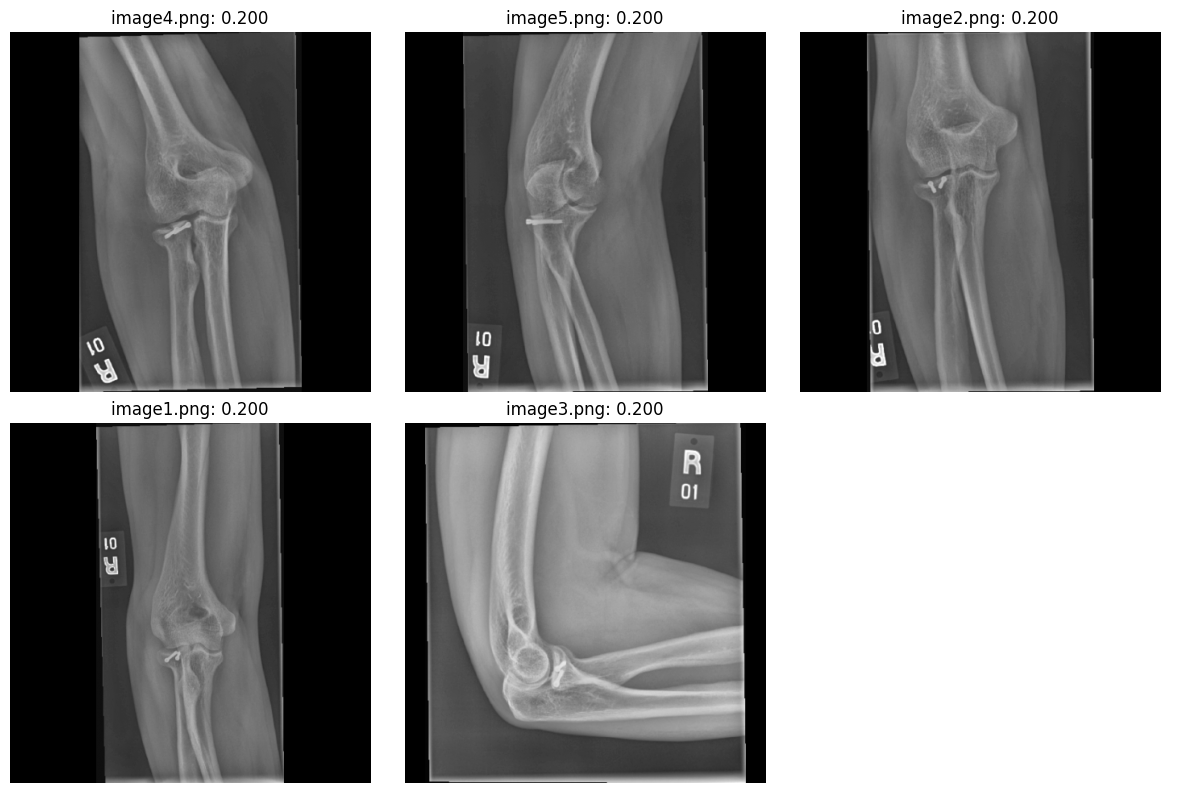

In [19]:
@torch.inference_mode()
def predict_study(dataset, idx=0):
    features, label, meta = dataset[idx]
    logits, attention = model(features.to(DEVICE))
    prob = torch.sigmoid(logits).item()
    return prob, label.item(), attention.squeeze(0).cpu().numpy(), meta

prob, label, attention, meta = predict_study(test_ds, idx=0)
image_paths = list_images(Path(meta["path"]))
ranking = pd.DataFrame({
    "image": [path.name for path in image_paths],
    "attention": attention,
}).sort_values("attention", ascending=False)

print({"prob": prob, "label": label, "study": meta["path"]})
display(ranking)

if plt is not None:
    top_paths = [Path(meta["path"]) / name for name in ranking["image"].head(6)]
    cols = min(3, len(top_paths))
    rows = int(np.ceil(len(top_paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, path in zip(axes, top_paths):
        ax.imshow(Image.open(path).convert("L"), cmap="gray")
        score = ranking.loc[ranking["image"] == path.name, "attention"].iloc[0]
        ax.set_title(f"{path.name}: {score:.3f}")
        ax.axis("off")
    for ax in axes[len(top_paths):]:
        ax.axis("off")
    plt.tight_layout()